# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an exploratory analysis of the historical cryptocurrency market data collected during the data acquisition stage.

This analysis aims to understand the structure, quality, and behavior of the dataset before any feature engineering or machine learning techniques are applied.

The notebook focuses on:

- Examining dataset dimensions and structure
- Assessing data quality and completeness
- Analyzing price behavior over time
- Exploring trading volume dynamics
- Investigating return characteristics and distributions
- Identifying patterns that may be useful for market regime detection

The insights obtained from this analysis will guide the feature engineering process and support the development of the market regime detection framework.

## Roadmap
1. Project Configuration
2. Load Dataset
3. Dataset Overview
4. Data Quality Assessment
5. Price Behavior Analysis
6. Volume Behavior Analysis
7. Return Analysis
8. Return Distribution Anlysis
9. Conclusion

------

## Project Configuration

This section loads the project configuration and paths required to access the datasets generated during the data collection stage.

Using a centralized configuration file ensures consistency and reproducibility across all notebooks in the project pipeline.

In [1]:
# ==========================================
# Import Libraries and Load Configuration
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
%matplotlib inline

# Absoulte Path To The Project Route
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)
    
from config import ASSETS, INTERVAL, RAW_DATA_PATH, PROCESSED_DATA_PATH

------

## Load Dataset

In this section, the raw historical market dataset collected during the data acquisition stage is loaded into memory.

The dataset contains the standard OHLCV variables together with the adjusted closing price.

In [2]:
# ==========================================
# Load Dataset
# ==========================================

if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)
file_path = f"{RAW_DATA_PATH}/{asset_name}_{INTERVAL}_raw.csv"

df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [3]:
# ==========================================
# Display Dataset Information
# ==========================================
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-01,13657.200195,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [4]:
# ==========================================
# Display Basic Information
# ==========================================
df.info()
df.columns

<class 'pandas.DataFrame'>
DatetimeIndex: 3144 entries, 2018-01-01 to 2026-08-10
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3144 non-null   float64
 1   Close      3144 non-null   float64
 2   High       3144 non-null   float64
 3   Low        3144 non-null   float64
 4   Open       3144 non-null   float64
 5   Volume     3144 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 171.9 KB


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

-------

## Dataset Overview

Before performing any exploratory analysis, it is important to understand the basic structure of the dataset.

This section examines:

- Dataset dimensions
- Available variables
- Data types
- Index structure

These checks help verify that the dataset was loaded correctly and is suitable for further analysis.

In [5]:
# ==========================================
# Dataset Dimensions
# ==========================================
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3144
Columns: 6


### Dataset Dimensions Interpretation

The dataset contains 3,081 observations and 6 financial variables, providing a substantial historical record of market activity across multiple market conditions.

The number of observations is sufficient for exploratory analysis, feature engineering, dimensionality reduction, and clustering techniques that will be applied in later stages of the project.

Additionally, the dataset includes both price-related variables and trading volume information, providing a solid foundation for identifying different market regimes.

In [6]:
# ==========================================
# Data Type Analysis
# ==========================================
df.dtypes

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

In [7]:
# ==========================================
# Display Index For Better Understanding
# ==========================================
print(type(df.index))
print(df.index[:5])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05'],
              dtype='datetime64[us]', name='Date', freq=None)


### Data Type Interpretation

All financial variables were loaded using appropriate numerical data types.

Price-related variables (Open, High, Low, Close, and Adjusted Close) are stored as float64 values, allowing for precise numerical calculations. Trading volume is stored as int64, which is appropriate because volume represents discrete transaction counts.

The Date variable is not displayed among the columns because it has been converted into a DatetimeIndex. This is the preferred structure for time-series analysis and will facilitate subsequent calculations, visualizations, and feature engineering tasks.

-----

## Data Quality Assessment

Data quality verification is a critical step before any statistical analysis or machine learning workflow.

This section evaluates:

- Missing values
- Dataset completeness
- Structural consistency

Ensuring data integrity at this stage helps prevent issues during feature engineering, dimensionality reduction, and clustering.

In [8]:
# ==========================================
# Missing Values Analysis 
# ==========================================
df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

### Missing Values Interpretation

The missing values analysis shows that no variables contain null observations.

This indicates that the dataset is complete and no imputation, interpolation, or row removal procedures are required before continuing with the analysis.

Having a complete dataset is particularly important for time-series modeling because missing observations can distort return calculations, rolling statistics, and clustering results. Therefore, the dataset is considered ready for the next stages of exploratory analysis and feature engineering.

------ 

## Price Behavior Analysis

In this section, we aim to answer the following questions in order to better understand the historical behavior of the selected asset:

- How has the selected asset evolved since 2018?
- Are there distinct market phases?
- Are there periods of unusually high growth or decline?

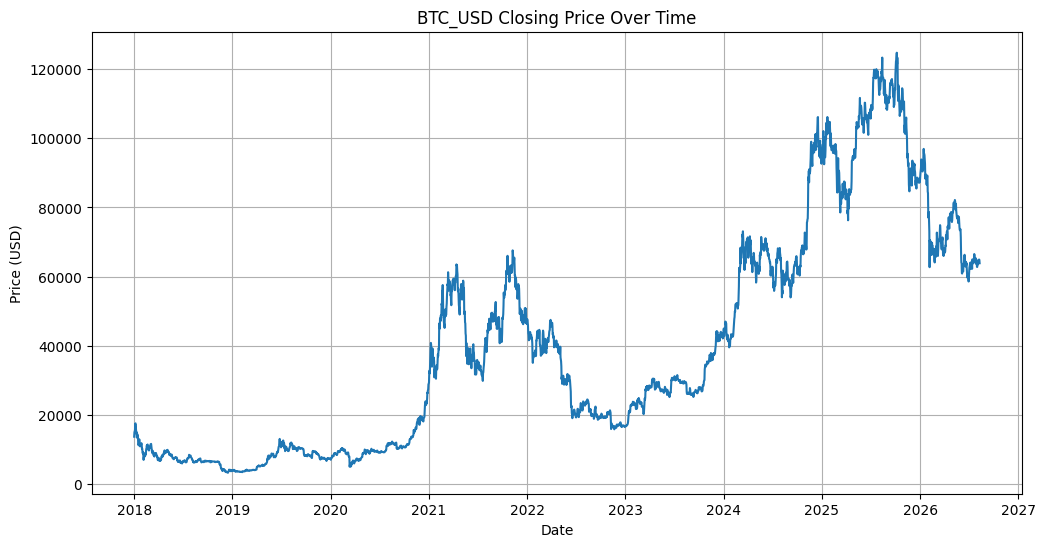

In [9]:
# ==========================================
# Price Behaivor Chart
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"])

plt.title(f"{asset_name.upper()} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)

## Interpretation of this chart

### Multiple Distinct Market Phases

The most important observation from the closing-price series is that Bitcoin does not exhibit a single consistent behavior throughout the observation period. Instead, the market alternates between periods of relative stability, strong appreciation, substantial declines, and recovery.

#### Phase 1: Lower-Price Period and Consolidation (2018–2020)

- Prices remain relatively low compared with later periods.
- The series shows periods of limited movement interrupted by shorter fluctuations.
- Overall price changes appear smaller than those observed during the major market cycles that follow.

This period provides an example of comparatively less intense market activity within the historical sample.

#### Phase 2: Strong Expansion (2020–2021)

- The price begins a pronounced upward trend.
- The increase becomes increasingly rapid as the market approaches its 2021 peak.
- Larger fluctuations become visible during the expansion.

This period demonstrates a substantial change in market dynamics compared with the preceding years.

#### Phase 3: Major Correction (2021–2022)

- The price declines substantially from the previous highs.
- The downward movement is accompanied by considerable fluctuations.
- The series continues to experience large changes before reaching lower price levels.

This period illustrates a pronounced contraction following the previous expansion.

#### Phase 4: Recovery and Stabilization (2022–2024)

- After reaching lower levels, the price begins to recover.
- The upward movement becomes more persistent through 2023 and into 2024.
- Price fluctuations remain present, although the behavior differs from the sharp movements observed during the previous major correction.

This period demonstrates a transition from the preceding decline toward renewed market growth.

#### Phase 5: Strong Expansion and New Highs (2024–2025)

- The price increases substantially during 2024 and 2025.
- The series reaches new historical highs.
- Large fluctuations remain visible throughout the expansion.

This represents another period of strong market growth with considerable price variability.

#### Phase 6: Correction and Increased Variability (2025–2026)

- The price declines significantly after reaching its historical peak.
- Several large upward and downward movements occur during the decline.
- The direction of the market becomes less consistently upward compared with the preceding expansion.

This period illustrates another substantial change in market behavior following a strong growth phase.

### Summary

The Bitcoin closing-price series exhibits substantial variation over time, characterized by alternating periods of growth, decline, recovery, and relative consolidation.

These visually distinguishable phases indicate that market behavior changes considerably throughout the observation period. Importantly, these phases are identified here only as **descriptive observations from the price series**, rather than as formally defined market regimes.

This observation motivates the use of return, volatility, and momentum features in the later stages of the project. By combining these characteristics and applying dimensionality reduction and clustering techniques, the project can formally identify and characterize distinct market regimes.

----- 

## Volume Behavior Analysis

Price movements alone do not fully describe market behavior. Trading volume provides information about market participation and can help identify periods of increased investor activity, speculation, accumulation, or panic selling.

In this section, we analyze the trading volume of the selected asset over time to answer the following questions:

- How has trading activity evolved since 2018?
- Are there periods of unusually high market participation?
- Do volume spikes coincide with major market events?
- Can volume help explain potential market regimes?

Understanding volume behavior is important because market regimes are often characterized not only by differences in price trends but also by differences in trading activity.

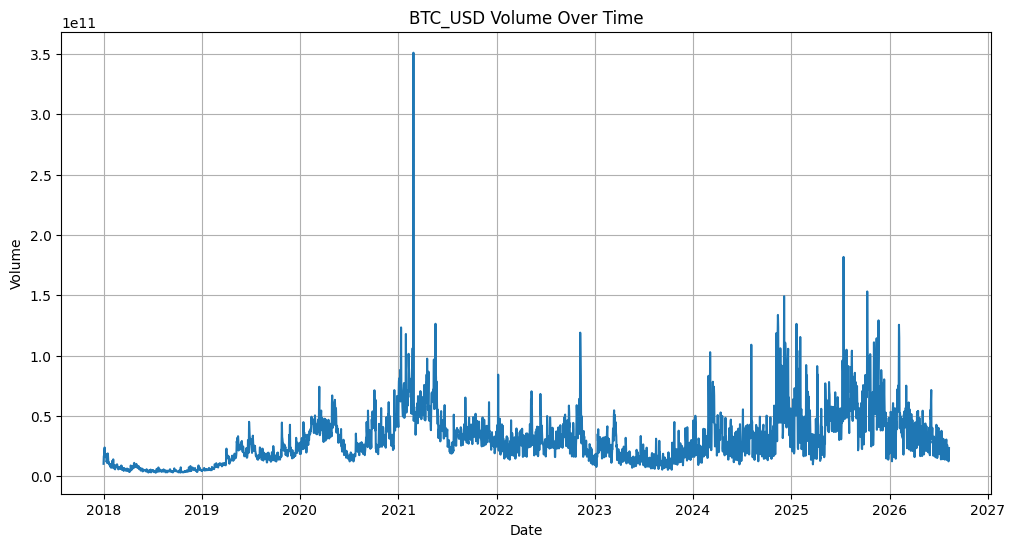

In [10]:
# ==========================================
# Volume Behavior Chart
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Volume"])

plt.title(f"{asset_name.upper()} Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

### Interpretation

The trading volume series reveals substantial changes in market participation throughout the observation period.

Trading activity remains relatively low during the early years of the dataset, particularly between 2018 and 2020. Beginning in 2020, volume increases considerably and several large spikes emerge, indicating periods of heightened market interest and trading activity.

A particularly notable feature is the extreme volume spike observed around 2021, suggesting an episode of exceptional market participation. Following this period, trading activity remains elevated compared to earlier years, indicating that the market structure may have evolved over time.

The volume behavior observed in the chart complements the findings from the price analysis. Periods of strong price movements are often accompanied by increased trading activity, providing additional evidence that the asset exhibits multiple market states characterized by different levels of participation, trend behavior, and volatility.

These observations further support the use of clustering techniques for identifying distinct market regimes in later stages of the project.

> ### 30-Day Rolling Average Volume

The daily trading volume chart provides valuable information about market activity; however, it is heavily influenced by short-term fluctuations and isolated volume spikes. These abrupt changes can make it difficult to identify broader trends in market participation.

To better understand the underlying behavior of trading activity, a 30-day rolling average is calculated. This technique smooths short-term fluctuations by averaging the trading volume over the previous 30 days.

The objective of this visualization is not to eliminate important market events, but rather to highlight long-term changes in participation levels and identify periods where market activity systematically increases or decreases.

By examining the smoothed volume series, we can more easily detect structural changes in market behavior that may correspond to different market regimes.

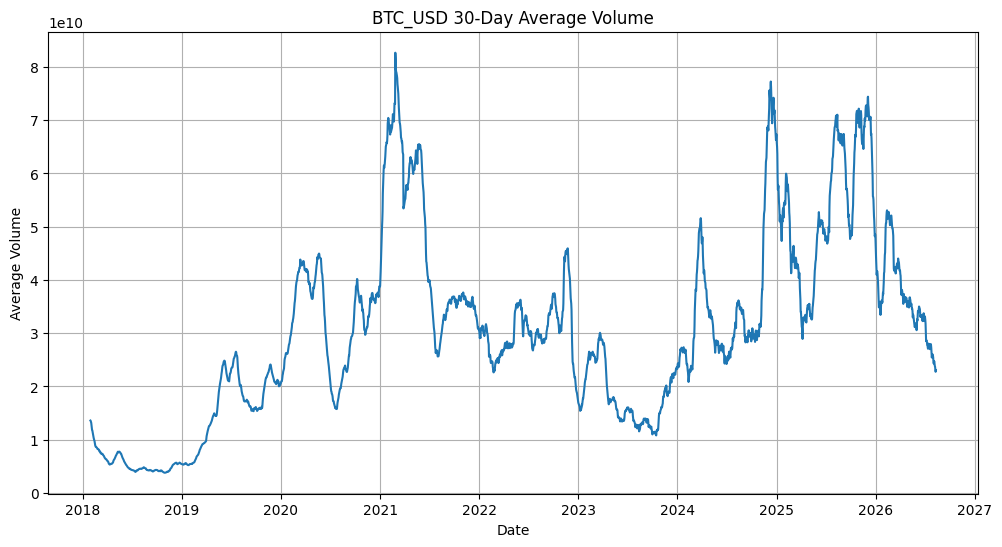

In [11]:
# ==========================================
# Rolling Average Volume Chart
# ==========================================
df["Volume_MA30"] = df["Volume"].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Volume_MA30"])

plt.title(f"{asset_name.upper()} 30-Day Average Volume")
plt.xlabel("Date")
plt.ylabel("Average Volume")

plt.grid(True)


### Interpretation

The 30-day rolling average volume reveals several long-term changes in market participation that were less visible in the daily volume chart.

From 2018 to early 2020, average trading activity remained relatively low and stable, indicating a period of comparatively limited market participation. Beginning in 2020, average volume increased substantially and remained elevated for extended periods, coinciding with the strong bullish market observed in the price analysis.

A major increase in average trading volume can be observed during 2021, suggesting a prolonged period of intense market activity rather than a single isolated event. Although trading activity declined after this period, it did not return to the levels observed during the early years of the dataset, indicating a structural change in market participation.

Additional periods of elevated average volume are visible during 2024 and 2025, corresponding to another phase of strong market movement. These sustained increases suggest that market activity tends to intensify during periods of significant price appreciation and uncertainty.

Compared with the raw volume chart, the rolling average highlights the underlying trend in market participation and provides clearer evidence that Bitcoin experiences distinct periods characterized by different levels of trading activity.

These findings further support the hypothesis that the market operates under multiple regimes, where participation, volatility, and price behavior vary substantially over time.

----- 

## Return Analysis

While price levels provide information about the long-term evolution of the selected asset, they do not directly describe the magnitude and direction of daily market movements.

For financial analysis, returns are often more informative than raw prices because they measure relative changes from one period to the next. Returns allow us to compare market behavior across different price levels and identify periods of growth, decline, and instability.

In the context of market regime detection, returns are particularly important because they form the basis for many financial indicators, including volatility and momentum, which will later be used for clustering analysis.

The objective of this section is to examine how Bitcoin returns behave over time and determine whether different periods exhibit distinct return characteristics.

In [12]:
# ==========================================
# Calculate Daily Returns
# ==========================================
df["Returns"] = df["Close"].pct_change()

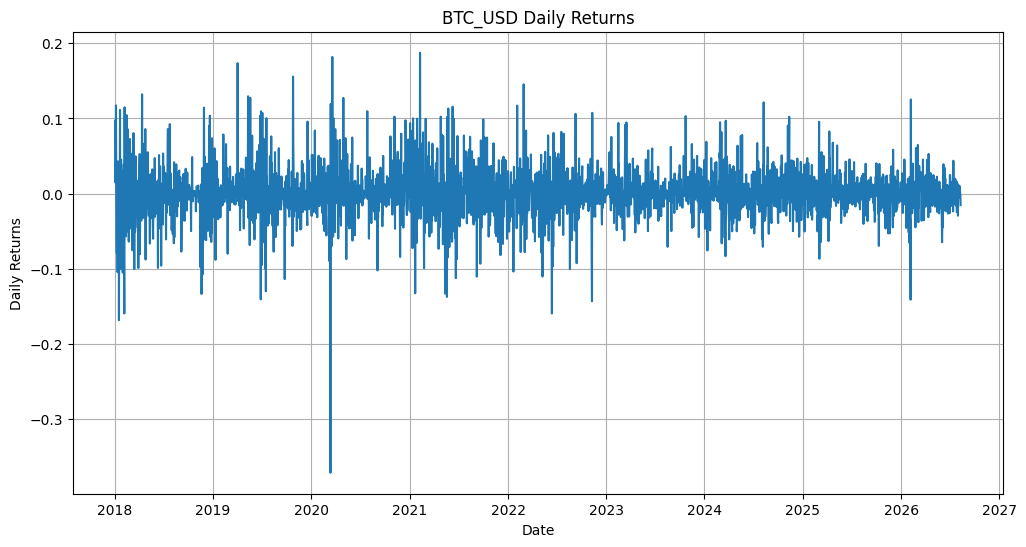

In [13]:
# ==========================================
# Visualize Through Time
# ==========================================
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Returns"])

plt.title(f"{asset_name.upper()} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Returns")

plt.grid(True)

### Interpretation

The daily return series fluctuates around zero throughout the observation period, indicating that positive and negative daily movements occur regularly over time.

Most daily returns remain centered around relatively small positive and negative movements, although their magnitude varies substantially across different periods. Some intervals exhibit relatively small daily changes, while others contain frequent large positive and negative movements.

Periods of elevated return variability are particularly visible around 2020–2022, suggesting that market uncertainty and volatility increased substantially during these years. Importantly, large return movements tend to occur in clusters rather than as isolated events, indicating that periods of high volatility are often followed by additional high-volatility observations.

These findings suggest that Bitcoin does not exhibit constant market behavior over time. Instead, the return series appears to transition between periods of lower and higher volatility, providing further evidence for the existence of distinct market regimes.

The presence of volatility clustering is particularly relevant for this project because volatility is expected to be one of the primary characteristics used to differentiate market regimes during the clustering stage.

-------

## Return Distribution Analysis

While the previous visualization showed how returns evolve through time, it does not reveal how returns are distributed overall.

Analyzing the distribution of returns helps identify common market behavior, the frequency of extreme events, and whether returns follow a normal distribution. Understanding these characteristics is important because many financial models assume normally distributed returns, while real financial markets often exhibit asymmetry and heavy tails.

The objective of this section is to examine the statistical distribution of daily asset returns and evaluate the presence of extreme observations that could influence market regime detection.

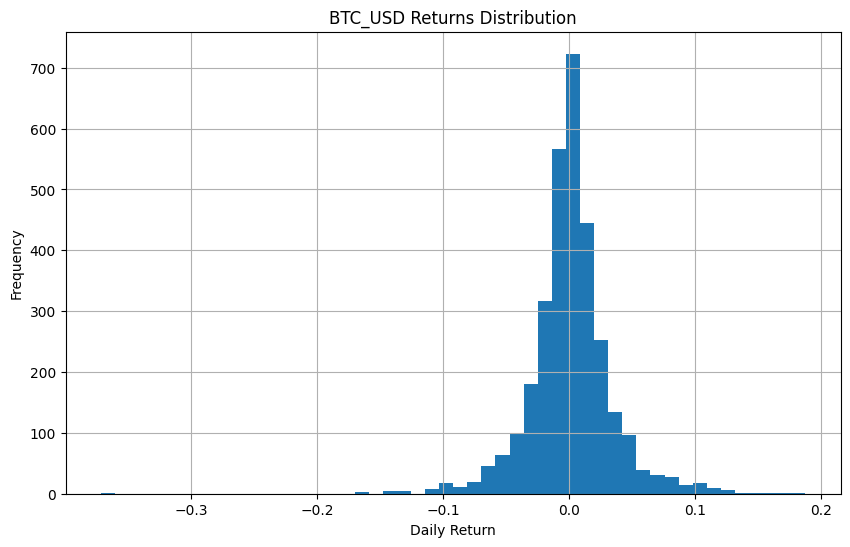

In [14]:
# ==========================================
# Return Distribution Chart
# ==========================================
plt.figure(figsize=(10,6))

plt.hist(
    df["Returns"].dropna(),
    bins=50
)

plt.title(f"{asset_name.upper()} Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

### Interpretation

The return distribution is heavily concentrated around zero, indicating that most daily price changes are relatively small. At the same time, the distribution contains observations in both the positive and negative tails, representing less frequent but substantially larger daily movements.

The histogram also shows a sharp central peak combined with relatively extended tails. This indicates that daily returns are not evenly distributed across the observed range and that extreme movements, although less frequent than small changes, are an important characteristic of the dataset.

The negative side of the distribution appears to contain some particularly large observations, suggesting that periods of substantial downside movement are present in the historical data. These extreme observations are relevant for the project because they can contribute to changes in volatility and therefore help distinguish between different market conditions.

Overall, the return distribution provides additional evidence that market behavior is not constant over time and that periods of relatively calm activity coexist with periods characterized by substantially larger price movements.

------

## Conclusion

The exploratory analysis confirms that the dataset is suitable for quantitative market analysis.

Key findings include:

- Complete historical records with no missing values or major structural issues identified
- Observable changes in price and volume dynamics
- Sustained changes in market activity revealed by the 30-day rolling volume
- Volatility clustering and the presence of substantial return observations

These observations provide valuable insight into market structure and establish a strong foundation for the next stage of the project: feature engineering and dimensionality reduction.